In [13]:
import numpy as np
import h5py
import healpy as hp
import healsparse
import matplotlib.pyplot as plt

import glob
import os

import pyarrow.parquet as pq
from pathlib import Path

import matplotlib.cm as cm
import sacc

import matplotlib.colors as mcolors
import sacc

### Convert fits mask to TXPipe MapsFile format

In [1]:
def fits_mask_to_txpipe(input_fits, output_hdf5, nside=None, nest=False):
    """
    
    Convert a FITS mask (e.g. from Mangle or Healpix) to the TXPipe MapsFile format.
    Parameters
    ----------
    input_fits : str
        Path to the input FITS file containing the mask. The mask should be in HEALPix format, with pixel values indicating masked/unmasked regions (e.g. 0 for masked,
        1 for unmasked). The FITS file should be in RING order by default, but the code will attempt to detect the ordering from the FITS header.
    output_hdf5 : str
        Path to the output HDF5 file in TXPipe MapsFile format.
    nside : int, optional
        The HEALPix nside parameter for the output mask. If None, the nside from the input FITS file will be used.
    nest : bool, optional
        Whether to use NESTED ordering for the output mask. If False, RING ordering will be used.
    Returns
    -------
    None
        The function writes the converted mask to the specified output HDF5 file.
    """
    # ---- 1. Read the FITS mask ----
    print(f"Reading mask from: {input_fits}")
    # Read in RING order by default (nest=False); healpy standard
    mask_full, header = hp.read_map(input_fits, dtype=np.float64, h=True)

    # Try to detect ordering from FITS header
    ordering = dict(header).get("ORDERING", "RING").strip().upper()
    nest = (ordering == "NESTED")
    print(f"  FITS ordering: {ordering} → nest={nest}")

    nside_fits = hp.get_nside(mask_full)
    if nside is not None and nside != nside_fits:
        print(f"  Upgrading/downgrading from nside={nside_fits} to nside={nside}")
        mask_full = hp.ud_grade(mask_full, nside, power=0, order_in="NESTED" if nest else "RING")
    else:
        nside = nside_fits

    print(f"  nside = {nside}, nest = {nest}")

    # ---- 2. Find unmasked pixels ----
    good = (mask_full != hp.UNSEEN) & (mask_full > 0)
    pixel = np.where(good)[0].astype(np.int64)
    value = mask_full[good].astype(np.float64)

    npix_total = hp.nside2npix(nside)
    n_unmasked = len(pixel)
    area_per_pixel_deg2 = hp.nside2pixarea(nside, degrees=True)
    area_deg2 = n_unmasked * area_per_pixel_deg2
    f_sky = n_unmasked / npix_total

    print(f"  Unmasked pixels : {n_unmasked:,} / {npix_total:,}")
    print(f"  Sky area        : {area_deg2:.2f} deg²")
    print(f"  f_sky           : {f_sky:.6f}")

    # ---- 3. Write TXPipe MapsFile layout ----
    print(f"Writing TXPipe mask to: {output_hdf5}")
    with h5py.File(output_hdf5, "w") as f:
        maps_group = f.create_group("maps")

        maps_group.attrs["pixelization"] = "healpix"
        maps_group.attrs["nside"] = nside
        maps_group.attrs["sparse"] = True
        maps_group.attrs["nest"] = nest

        mask_group = maps_group.create_group("mask")
        mask_group.create_dataset("pixel", data=pixel)
        mask_group.create_dataset("value", data=value)

        mask_group.attrs["pixelization"] = "healpix"
        mask_group.attrs["nside"] = nside
        mask_group.attrs["nest"] = nest          # ← this was missing
        mask_group.attrs["area"] = area_deg2
        mask_group.attrs["f_sky"] = f_sky
        mask_group.attrs["npix"] = npix_total
        mask_group.attrs["sparse"] = True
        mask_group.attrs["n_unmasked"] = n_unmasked

    print("Done.")

In [3]:
output_hdf5 = '/pscratch/sd/a/anicola/DP2/data/masks/dp2_mask.hdf5'
input_fits = '/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/masks/dp2_mask.fits'

In [4]:
fits_mask_to_txpipe(input_fits, output_hdf5, 512)

Reading mask from: /global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/masks/dp2_mask.fits
  FITS ordering: RING → nest=False
  Upgrading/downgrading from nside=256 to nside=512
  nside = 512, nest = False
  Unmasked pixels : 280,620 / 3,145,728
  Sky area        : 3680.04 deg²
  f_sky           : 0.089207
Writing TXPipe mask to: /pscratch/sd/a/anicola/DP2/data/masks/dp2_mask.hdf5
Done.


In [5]:
mask = hp.read_map(input_fits)

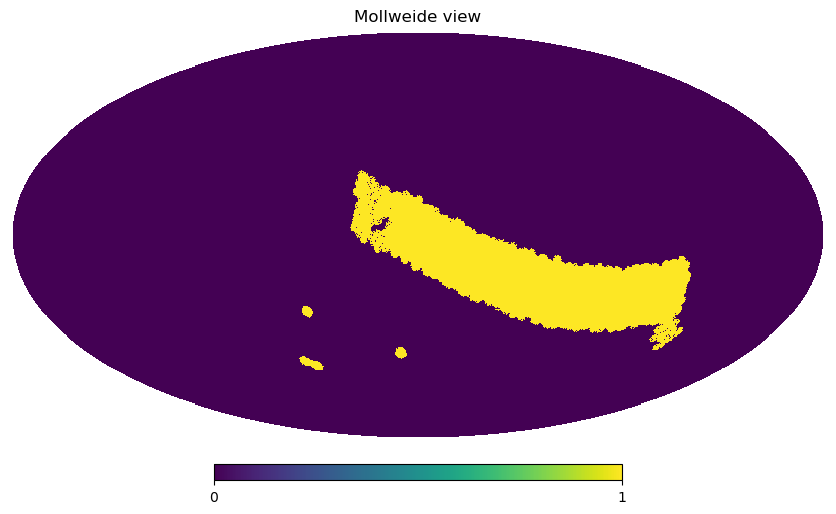

In [6]:
hp.mollview(mask)

### Convert heaplix map to healsparse

In [7]:
def healpix_to_healsparse(
    input_path,
    output_path,
    nside_sparse=None,
    nside_coverage=32,
    sentinel=None,
):
    """
    Convert a single HEALPix FITS map to a HealSparse map.

    Parameters
    ----------
    input_path : str
        Path to the input HEALPix FITS file.
    output_path : str
        Path for the output HealSparse (.hsp) file.
    nside_sparse : int or None
        nside of the output HealSparse map. If None, the nside of the
        input FITS map is used. If different from the input nside,
        the map is up/downgraded before conversion.
    nside_coverage : int
        nside of the coarse HealSparse coverage map (default 32,
        which is the TXPipe convention).
    sentinel : float or None
        Value representing missing data. Defaults to hp.UNSEEN.
    """
    if sentinel is None:
        sentinel = hp.UNSEEN

    # ---- 1. Read the FITS map ----
    print(f"Reading: {input_path}")
    raw, header = hp.read_map(input_path, dtype=np.float64, h=True)
    header_dict = dict(header)

    ordering = header_dict.get("ORDERING", "RING").strip().upper()
    nest_in = (ordering == "NESTED")
    nside_in = hp.get_nside(raw)
    print(f"  nside={nside_in}, ordering={ordering}")

    # ---- 2. Resample if a different nside_sparse was requested ----
    if nside_sparse is None:
        nside_sparse = nside_in
    elif nside_sparse != nside_in:
        print(f"  Resampling from nside={nside_in} to nside={nside_sparse}")
        # ud_grade expects RING order
        if nest_in:
            raw = hp.reorder(raw, n2r=True)
            nest_in = False
        raw = hp.ud_grade(raw, nside_sparse, power=0)
        # Mark resampled pixels that averaged to sentinel as invalid
        raw[raw == sentinel] = sentinel

    print(f"  Output nside_sparse={nside_sparse}")

    # ---- 3. Convert to NESTED order (required by HealSparse) ----
    if not nest_in:
        raw = hp.reorder(raw, r2n=True)

    # ---- 4. Find valid pixels ----
    valid_pixels = np.where((raw != sentinel) & np.isfinite(raw))[0]
    values = raw[valid_pixels].astype(np.float64)
    n_valid = len(valid_pixels)
    f_sky = n_valid / hp.nside2npix(nside_sparse)
    print(f"  Valid pixels: {n_valid:,} / {hp.nside2npix(nside_sparse):,} (f_sky={f_sky:.4f})")
    print(f"  Value range : [{values.min():.4f}, {values.max():.4f}]")

    # ---- 5. Build and write the HealSparse map ----
    hsp = healsparse.HealSparseMap.make_empty(
        nside_coverage=nside_coverage,
        nside_sparse=nside_sparse,
        dtype=np.float64,
        sentinel=sentinel,
    )
    hsp.update_values_pix(valid_pixels, values, nest=True)
    hsp.write(output_path, clobber=True)
    print(f"Written: {output_path}")


In [8]:
directory = "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/"

fits_files = glob.glob(os.path.join(directory, "*.fits"))

print(fits_files)

['/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/lsstcam_20250930_Median_seeingFwhmEff_y_and_observation_reason_!_field_survey_science_and_fiveSigmaDepth_is_not_NULL_HEAL.fits', '/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/lsstcam_20250930_ExgalM5_r_and_observation_reason_!_field_survey_science_and_fiveSigmaDepth_is_not_NULL_HEAL.fits', '/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/lsstcam_20250930_Median_seeingFwhmEff_u_and_observation_reason_!_field_survey_science_and_fiveSigmaDepth_is_not_NULL_HEAL.fits', '/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/lsstcam_20250930_Median_seeingFwhmEff_i_and_observation_reason_!_field_survey_science_and_fiveSigmaDepth_is_not_NULL_HEAL.fits', '/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/lsstcam_20250930_ExgalM5_y_and_observation_reason_!_field_survey_science_and_fiveSigmaDepth_is_not_NULL_HEAL.fits', '/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/lsstcam_20250930_ExgalM5_i_and_observation_reason_

In [9]:
path_2_systmaps = '/pscratch/sd/a/anicola/DP2/data/sysmaps'

In [35]:
for file in fits_files:
    print('Converting {} to healsparse.'.format(file))
    filename = os.path.basename(file)
    name_without_ext = os.path.splitext(filename)[0]
    output_path = os.path.join(path_2_systmaps, name_without_ext+'.hs')
    print(output_path)
    healpix_to_healsparse(file, output_path, nside_sparse=512)

Converting /global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/lsstcam_20250930_Median_seeingFwhmEff_y_and_observation_reason_!_field_survey_science_and_fiveSigmaDepth_is_not_NULL_HEAL.fits to healsparse.
/pscratch/sd/a/anicola/DP2/data/sysmaps/lsstcam_20250930_Median_seeingFwhmEff_y_and_observation_reason_!_field_survey_science_and_fiveSigmaDepth_is_not_NULL_HEAL.hs
Reading: /global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/lsstcam_20250930_Median_seeingFwhmEff_y_and_observation_reason_!_field_survey_science_and_fiveSigmaDepth_is_not_NULL_HEAL.fits
  nside=256, ordering=RING
  Resampling from nside=256 to nside=512
  Output nside_sparse=512
  Valid pixels: 227,312 / 3,145,728 (f_sky=0.0723)
  Value range : [0.6738, 2.3318]
Written: /pscratch/sd/a/anicola/DP2/data/sysmaps/lsstcam_20250930_Median_seeingFwhmEff_y_and_observation_reason_!_field_survey_science_and_fiveSigmaDepth_is_not_NULL_HEAL.hs
Converting /global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps/lsstcam_20250930_Exga

### Compute catalog n(z) and save to qp file

In [10]:
def compute_nz(
    redshifts,
    tomo_bins,
    z_min=0.0,
    z_max=3.0,
    n_z=300,
    weights=None,
):
    """
    Compute normalised n(z) histograms for each tomographic bin.

    Parameters
    ----------
    redshifts : np.ndarray, shape (ngal,)
        Redshift value for each galaxy.
    tomo_bins : np.ndarray, shape (ngal,), dtype int
        Tomographic bin index for each galaxy (0-based).
        Galaxies with bin index -1 are treated as unselected and excluded.
    z_min : float
        Minimum redshift edge (default 0.0).
    z_max : float
        Maximum redshift edge (default 3.0).
    n_z : int
        Number of redshift histogram bins (default 300).
    weights : np.ndarray, shape (ngal,) or None
        Optional per-galaxy weights.  If None, all galaxies are weighted
        equally.

    Returns
    -------
    z_edges : np.ndarray, shape (n_z+1,)
        Redshift bin edges, suitable for passing to save_nz_to_qpnofzfile().
    nzs : list of np.ndarray, each shape (n_z,)
        Normalised n(z) for each tomographic bin.  Each array integrates
        to 1 over z_edges.  Order matches the unique bin indices found in
        tomo_bins (0, 1, 2, ...).
    """
    redshifts = np.asarray(redshifts, dtype=np.float64)
    tomo_bins = np.asarray(tomo_bins, dtype=np.int32)

    if weights is None:
        weights = np.ones(len(redshifts), dtype=np.float64)
    else:
        weights = np.asarray(weights, dtype=np.float64)

    if len(redshifts) != len(tomo_bins):
        raise ValueError(
            f"redshifts and tomo_bins must have the same length, "
            f"got {len(redshifts)} and {len(tomo_bins)}"
        )

    # ---- 1. Build redshift grid ----
    z_edges = np.linspace(z_min, z_max, n_z + 1)
    z_mid   = 0.5 * (z_edges[:-1] + z_edges[1:])

    # ---- 2. Find tomographic bins (excluding unselected galaxies, bin=-1) ----
    selected = tomo_bins >= 0
    unique_bins = np.arange(tomo_bins[selected].max() + 1)
    nbin = len(unique_bins)

    print(f"Computing n(z) for {nbin} tomographic bins")
    print(f"  z range : [{z_min:.3f}, {z_max:.3f}]  n_z={n_z}")
    print(f"  Total galaxies    : {len(redshifts):,}")
    print(f"  Selected galaxies : {selected.sum():,}")

    # ---- 3. Histogram each bin ----
    nzs = []
    for b in unique_bins:
        mask = (tomo_bins == b)
        n_gal_in_bin = mask.sum()

        hist, _ = np.histogram(
            redshifts[mask],
            bins=z_edges,
            weights=weights[mask],
        )
        hist = hist.astype(np.float64)

        # Normalise so the n(z) integrates to 1
        norm = np.trapz(hist, z_mid)
        if norm > 0:
            hist /= norm
        else:
            print(f"  WARNING: bin {b} has zero total weight — n(z) will be all zeros")

        nzs.append(hist)

        peak_z = z_mid[np.argmax(hist)] if norm > 0 else float("nan")
        print(f"  bin {b}: {n_gal_in_bin:,} galaxies, peak n(z) at z={peak_z:.3f}")

    return z_edges, nzs

In [11]:
def save_nz_to_qpnofzfile(z_edges, nzs, output_path):
    """
    Save tomographic n(z) arrays as a TXPipe QPNOfZFile.

    Parameters
    ----------
    z_edges : np.ndarray, shape (n_z+1,)
        Edges of the redshift grid.  Must have one more element than
        each n(z) array.
    nzs : list of np.ndarray, each shape (n_z,)
        Normalised n(z) for each tomographic bin, evaluated at the
        bin centres implied by z_edges.  The 2D n(z) (sum over all
        bins) is appended automatically as the final row, following
        the TXPipe convention.
    output_path : str
        Path for the output file.  Should end in .hdf5.
    """
    import qp
    from txpipe.data_types import QPNOfZFile

    nbin = len(nzs)
    n_z  = len(z_edges) - 1
    z_mid = 0.5 * (z_edges[:-1] + z_edges[1:])

    # ---- 1. Stack into array of shape (nbin, n_z) ----
    nz_array = np.array(nzs, dtype=np.float64)   # (nbin, n_z)

    if nz_array.shape[1] != n_z:
        raise ValueError(
            f"Each n(z) array must have length {n_z} (= len(z_edges)-1), "
            f"but got shape {nz_array.shape}"
        )

    # ---- 2. Normalise each bin so it integrates to 1 ----
    for i in range(nbin):
        norm = np.trapz(nz_array[i], z_mid)
        if norm > 0:
            nz_array[i] /= norm

    # ---- 3. Append the 2D n(z) as the final row (TXPipe convention) ----
    nz_2d = nz_array.sum(axis=0)
    norm_2d = np.trapz(nz_2d, z_mid)
    if norm_2d > 0:
        nz_2d /= norm_2d
    pdfs = np.vstack([nz_array, nz_2d])   # shape (nbin+1, n_z)

    # ---- 4. Build qp Ensemble (hist type, same as TXTruePhotozStack) ----
    # qp.hist expects:
    #   bins : shape (n_z+1,)   — the edges
    #   pdfs : shape (nbin+1, n_z) — the heights (will be transposed internally)
    q = qp.Ensemble(
        qp.hist,
        data={"bins": z_edges, "pdfs": pdfs},
    )

    # ---- 5. Write using QPNOfZFile.write_ensemble ----
    with QPNOfZFile(output_path, "w") as f:
        f.write_ensemble(q)

    print(f"Written {nbin} tomographic bins + 1 2D bin to: {output_path}")
    print(f"  z range  : [{z_edges[0]:.3f}, {z_edges[-1]:.3f}]")
    print(f"  n_z bins : {n_z}")
    for i in range(nbin):
        peak_z = z_mid[np.argmax(nz_array[i])]
        print(f"  tomo bin {i}: peak at z={peak_z:.3f}")
    print(f"  2D n(z)  : peak at z={z_mid[np.argmax(nz_2d)]:.3f}")

In [3]:
# this is where the catalogues sit, it's split into a few chunks:
root="/pscratch/sd/q/qhang/Flagship/dp2_mock_run_flagship_gold_test/"
pixels=[24811,  24812,  24813,  24814,  24815,  24816,  24817,  24818]
parquet_name = "output_deredden_lsst_obs_cond_dp2.pq"

# ! note the truth catalogue has a cut at i < 24.5!!! This is a bit shallow. 
# I can grab some data for i<26 to make it more complete. 
flist=[]
for pix in pixels:
    flist.append(root + f"{pix}/" + parquet_name)
print(flist)

['/pscratch/sd/q/qhang/Flagship/dp2_mock_run_flagship_gold_test/24811/output_deredden_lsst_obs_cond_dp2.pq', '/pscratch/sd/q/qhang/Flagship/dp2_mock_run_flagship_gold_test/24812/output_deredden_lsst_obs_cond_dp2.pq', '/pscratch/sd/q/qhang/Flagship/dp2_mock_run_flagship_gold_test/24813/output_deredden_lsst_obs_cond_dp2.pq', '/pscratch/sd/q/qhang/Flagship/dp2_mock_run_flagship_gold_test/24814/output_deredden_lsst_obs_cond_dp2.pq', '/pscratch/sd/q/qhang/Flagship/dp2_mock_run_flagship_gold_test/24815/output_deredden_lsst_obs_cond_dp2.pq', '/pscratch/sd/q/qhang/Flagship/dp2_mock_run_flagship_gold_test/24816/output_deredden_lsst_obs_cond_dp2.pq', '/pscratch/sd/q/qhang/Flagship/dp2_mock_run_flagship_gold_test/24817/output_deredden_lsst_obs_cond_dp2.pq', '/pscratch/sd/q/qhang/Flagship/dp2_mock_run_flagship_gold_test/24818/output_deredden_lsst_obs_cond_dp2.pq']


In [4]:
redshifts = []

for f in flist:
    table = pq.read_table(f, columns=["redshift"])
    redshifts.append(table["redshift"].to_numpy())

redshift_array = np.concatenate(redshifts)

print(redshift_array)

[1.6120354 1.6380118 1.6221359 ... 2.9332745 2.8631902 2.9939973]


In [6]:
tomo_bins = np.array([0.2, 0.4, 0.6, 0.8])

inds = np.digitize(redshift_array, tomo_bins) - 1
valid = (inds >= 0) & (inds < len(tomo_bins) - 1)

z = redshift_array[valid]
inds = inds[valid]

In [8]:
z_edges, nz = compute_nz(z, inds)

Computing n(z) for 3 tomographic bins
  z range : [0.000, 3.000]  n_z=300
  Total galaxies    : 89,787,583
  Selected galaxies : 89,787,583


/tmp/ipykernel_2178979/1502299723.py:99: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(hist, z_mid)


  bin 0: 25,089,164 galaxies, peak n(z) at z=0.395
  bin 1: 31,866,893 galaxies, peak n(z) at z=0.585
  bin 2: 32,831,526 galaxies, peak n(z) at z=0.675


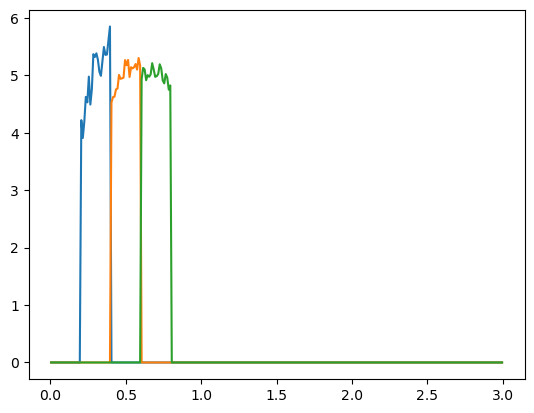

In [10]:
z_mid = 0.5 * (z_edges[:-1] + z_edges[1:])

for i in range(len(nz)):
    plt.plot(z_mid, nz[i])

In [11]:
save_nz_to_qpnofzfile(z_edges, nz, "data/outputs/lens_photoz_stack.hdf5")

Written 3 tomographic bins + 1 2D bin to: data/outputs/lens_photoz_stack.hdf5
  z range  : [0.000, 3.000]
  n_z bins : 300
  tomo bin 0: peak at z=0.395
  tomo bin 1: peak at z=0.585
  tomo bin 2: peak at z=0.675
  2D n(z)  : peak at z=0.395


/tmp/ipykernel_2178979/1164361802.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(nz_array[i], z_mid)
/tmp/ipykernel_2178979/1164361802.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_2d = np.trapz(nz_2d, z_mid)


### Plot Cls

In [14]:
def load_cls(sacc_file):
    """
    Load all C_ell measurements from the SACC file, grouped by data type.

    Returns a dict:
        {
          "cl_ee":  [(i, j, ell, cl, err), ...],   # shear-shear
          "cl_eb":  [...],
          "cl_bb":  [...],
          "cl_0e":  [...],                           # galaxy-shear
          "cl_0b":  [...],
          "cl_00":  [...],                           # galaxy-galaxy
        }
    """
    s = sacc.Sacc.load_fits(sacc_file)

    # All data types present in the file
    data_types = set(dp.data_type for dp in s.data)
    print(f"Data types found: {sorted(data_types)}")

    results = {}
    for dt in sorted(data_types):
        tracers = s.get_tracer_combinations(dt)
        entries = []
        for (t1, t2) in tracers:
            try:
                ell, cl, cov = s.get_ell_cl(dt, t1, t2, return_cov=True)
                err = np.sqrt(np.diag(cov))
            except Exception:
                ell, cl = s.get_ell_cl(dt, t1, t2, return_cov=False)            
                err = np.zeros_like(cl)
            entries.append((t1, t2, ell, cl, err))
        results[dt] = entries

    return s, results



# ---------------------------------------------------------------------------
# Distinct colours — one per bin pair, visually well-separated
# ---------------------------------------------------------------------------
COLORS = [
    "#E6194B",  # red
    "#3CB44B",  # green
    "#4363D8",  # blue
    "#F58231",  # orange
    "#911EB4",  # purple
    "#42D4F4",  # cyan
    "#F032E6",  # magenta
    "#BFEF45",  # lime
    "#FABED4",  # pink
    "#469990",  # teal
    "#DCBEFF",  # lavender
    "#9A6324",  # brown
]


def load_cls(sacc_file):
    """
    Load all C_ell measurements grouped by data type and bin pair.

    Returns
    -------
    s : sacc.Sacc
    results : dict  { data_type: [(t1, t2, ell, cl, err), ...] }
    """
    s = sacc.Sacc.load_fits(sacc_file)
    data_types = set(dp.data_type for dp in s.data)
    print(f"Data types found: {sorted(data_types)}")

    results = {}
    for dt in sorted(data_types):
        tracers = s.get_tracer_combinations(dt)
        entries = []
        for (t1, t2) in tracers:
            ell, cl = s.get_ell_cl(dt, t1, t2)
            try:
                indices = s.indices(dt, (t1, t2))
                cov = s.covariance.dense[np.ix_(indices, indices)]
                err = np.sqrt(np.diag(cov))
            except Exception:
                err = np.zeros_like(cl)
            entries.append((t1, t2, ell, cl, err))
        results[dt] = entries

    return s, results


def parse_bin_index(tracer_name):
    """Extract integer bin index from a tracer name like 'lens_2'."""
    parts = tracer_name.rsplit("_", 1)
    try:
        return int(parts[-1])
    except ValueError:
        return 0


def bin_label(tracer_name):
    """Turn 'lens_0' into 'Lens 0', 'source_1' into 'Source 1' etc."""
    parts = tracer_name.rsplit("_", 1)
    if len(parts) == 2:
        return f"{parts[0].capitalize()} {parts[1]}"
    return tracer_name


def data_type_label(dt):
    labels = {
        "cl_00": r"$C_\ell^{gg}$",
        "cl_0e": r"$C_\ell^{g\kappa}$",
        "cl_0b": r"$C_\ell^{gB}$",
        "cl_ee": r"$C_\ell^{\kappa\kappa}$\ (EE)",
        "cl_eb": r"$C_\ell^{\kappa\kappa}$\ (EB)",
        "cl_bb": r"$C_\ell^{\kappa\kappa}$\ (BB)",
    }
    return labels.get(dt, dt)


def plot_cls(sacc_file, output_path):
    """
    Create a grid of C_ell plots from the SACC file, one subplot per bin pair.
    Parameters
    ----------
    sacc_file : str
        Path to the input SACC file containing the C_ell measurements.
    output_path : str
        Path to the output file where the plot will be saved.
    """
    s, results = load_cls(sacc_file)

    # --- Collect all tracer names and sort by bin index ---
    all_tracers = sorted(
        set(t for entries in results.values() for (t1, t2, *_) in entries for t in (t1, t2)),
        key=lambda t: (t.rsplit("_", 1)[0], parse_bin_index(t)),
    )
    nbin = len(all_tracers)
    tracer_idx = {t: i for i, t in enumerate(all_tracers)}

    if nbin == 0:
        print("No tracers found.")
        return

    # --- One subplot grid per data type ---
    for dt, entries in results.items():
        if not entries:
            continue

        fig, axes = plt.subplots(
            nbin, nbin,
            figsize=(3.5 * nbin, 3.2 * nbin),
            squeeze=False,
            sharex=False, sharey=False,
        )
        fig.suptitle(
            f"TXPipe  {data_type_label(dt)}",
            fontsize=15, y=1.01,
        )

        # Hide all panels by default; only show those with data
        for r in range(nbin):
            for c in range(nbin):
                axes[r][c].set_visible(False)

        # Assign a distinct colour to each bin pair
        color_map = {
            (t1, t2): COLORS[k % len(COLORS)]
            for k, (t1, t2, *_) in enumerate(entries)
        }

        for (t1, t2, ell, cl, err) in entries:
            i = tracer_idx[t1]
            j = tracer_idx[t2]

            # Put auto-correlations on diagonal, cross on lower triangle
            # Always use lower triangle (i >= j)
            if i < j:
                i, j = j, i

            ax = axes[i][j]
            ax.set_visible(True)
            color = color_map[(t1, t2)]

            factor = ell * (ell + 1) / (2 * np.pi)
            y      = factor * cl
            y_err  = factor * err
            has_err = np.any(err > 0)

            if has_err:
                ax.errorbar(
                    ell, y, yerr=y_err,
                    fmt="o", ms=4, lw=1.5, capsize=2,
                    color=color,
                )
            else:
                ax.plot(ell, y, "o-", ms=4, lw=1.5, color=color)

            # Negative values: open downward triangles on |y|
            neg = y < 0
            if neg.any():
                ax.plot(
                    ell[neg], np.abs(y[neg]),
                    "v", ms=7, color=color, alpha=0.6,
                    markerfacecolor="none", markeredgewidth=1.5,
                )

            ax.set_xscale("log")

            # Use symlog so negatives are visible without crashing log scale
            y_abs_max = np.max(np.abs(y[np.isfinite(y)])) if np.any(np.isfinite(y)) else 1.0
            linthresh = max(y_abs_max * 1e-3, 1e-10)
            ax.set_yscale("symlog", linthresh=linthresh)

            ax.grid(True, which="both", ls=":", alpha=0.35)

            # Panel title
            if i == j:
                ax.set_title(
                    f"{bin_label(t1)}  (auto)",
                    fontsize=9, fontweight="bold",
                )
            else:
                ax.set_title(
                    f"{bin_label(t1)} × {bin_label(t2)}",
                    fontsize=9,
                )

            if i == j:
                ax.set_ylim(5e-2, 8e-1)
            else:
                ax.set_ylim(1e-3, 5e-1)

            # Axis labels only on edges
            if i == nbin - 1 or (j == nbin - 1 and i == nbin - 1):
                ax.set_xlabel(r"$\ell$", fontsize=10)
            if j == 0:
                ax.set_ylabel(
                    r"$\ell(\ell+1)C_\ell/2\pi$", fontsize=9
                )

        # Add shared axis labels on the outer edges
        for c in range(nbin):
            # Find the bottom-most visible panel in this column
            for r in range(nbin - 1, -1, -1):
                if axes[r][c].get_visible():
                    axes[r][c].set_xlabel(r"$\ell$", fontsize=10)
                    break
        for r in range(nbin):
            for c in range(nbin):
                if axes[r][c].get_visible():
                    axes[r][c].set_ylabel(
                        r"$\ell(\ell+1)C_\ell/2\pi$", fontsize=9
                    )
                    break

        plt.tight_layout()

        # One output file per data type
        stem = output_path.rsplit(".", 1)
        if len(stem) == 2:
            out = f"{stem[0]}_{dt}.{stem[1]}"
        else:
            out = f"{output_path}_{dt}.png"

        # plt.savefig(out, dpi=150, bbox_inches="tight")
        # print(f"Saved: {out}")
        # plt.close()


In [22]:
sacc_file = '/pscratch/sd/a/anicola/DP2/code/TXPipe/data/outputs/dp2_23p5/summary_statistics_fourier.sacc'

In [23]:
output_path = ''

Data types found: ['galaxy_density_cl']


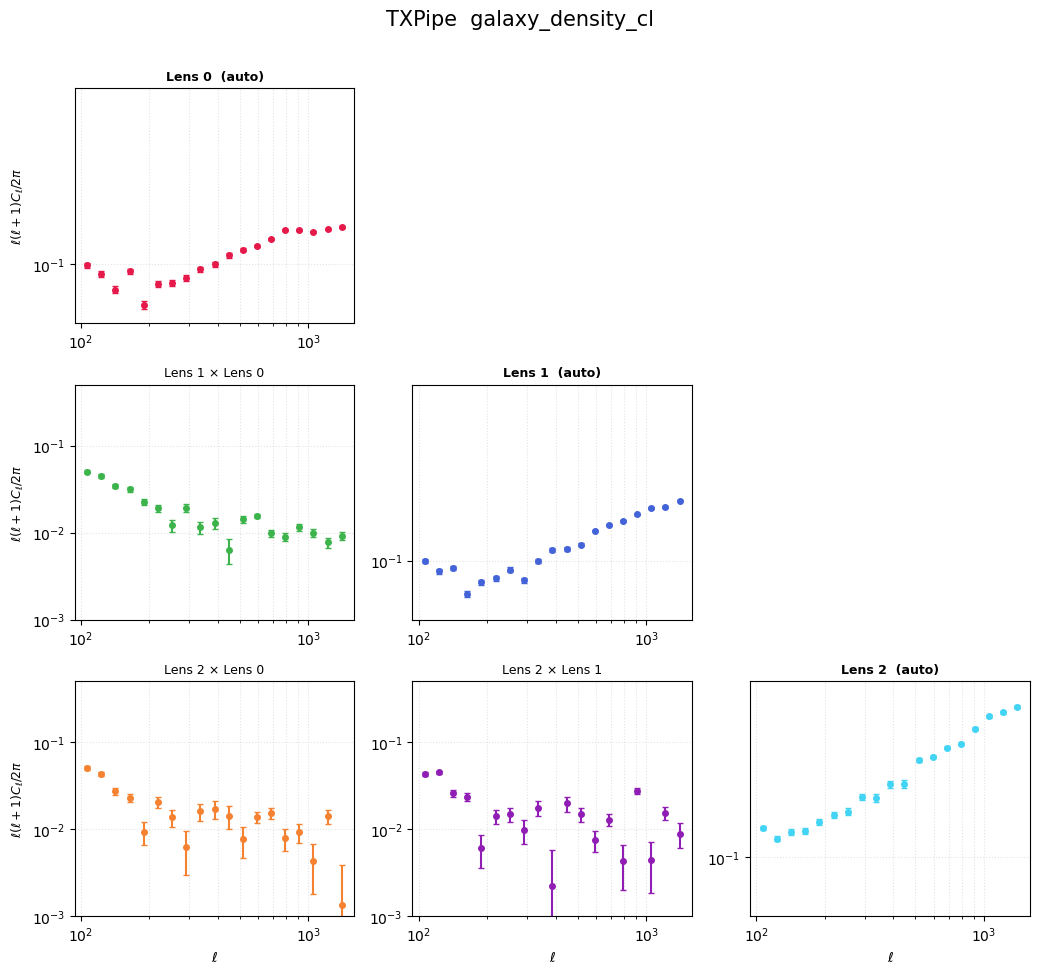

In [24]:
plot_cls(sacc_file, output_path)